In [1]:
import numpy as np
import numpy as np
import matplotlib.pyplot as plt

data = np.load('datavsp_01.npy')

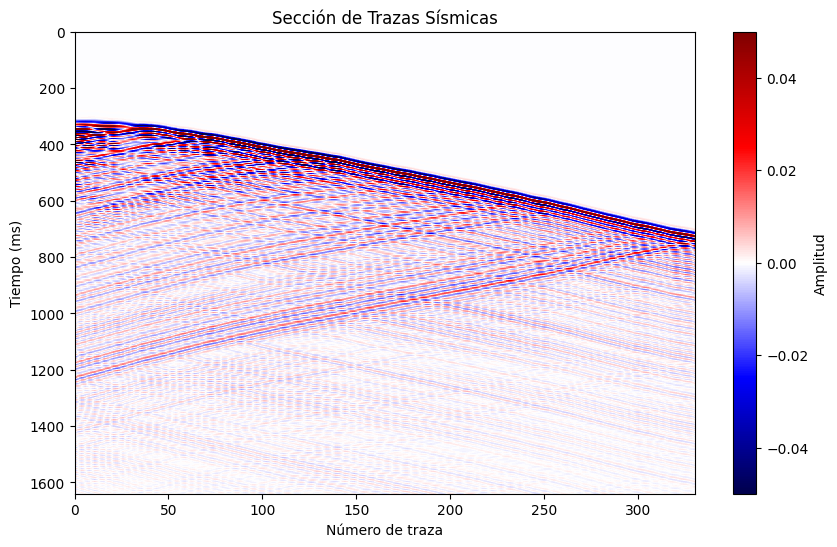

In [2]:
# Configuración para graficar las trazas sísmicas
clip = 5e-2
vmin, vmax = -clip, clip
plt.figure(figsize=(10, 6))
plt.imshow(data.T, aspect='auto', cmap='seismic', extent=[0, 330, 1640, 0], vmin=vmin, vmax=vmax)
plt.colorbar(label="Amplitud")
plt.xlabel("Número de traza")
plt.ylabel("Tiempo (ms)")
plt.title("Sección de Trazas Sísmicas")
plt.show()

In [3]:
import numpy as np
from scipy.signal import fftconvolve

def wiener_deconvolution_sismic(y, h, noise_var):
    """
    Implementa la deconvolución usando el método de filtrado de Wiener.

    Parámetros:
        y (array): Traza sísmica observada.
        h (array): Respuesta impulsiva estimada.
        noise_var (float): Varianza del ruido estimada.

    Retorna:
        x_est (array): Señal deseada estimada (x(t)).
    """
    # Transformada de Fourier de la señal y del sistema
    Y = np.fft.fft(y, n=len(y) + len(h) - 1)
    H = np.fft.fft(h, n=len(y) + len(h) - 1)

    # Densidad espectral de potencia aproximada
    P_xx = np.abs(H)**2 / len(h)  # Aproximación basada en h
    P_nn = noise_var

    # Filtro de Wiener
    H_wiener = np.conj(H) * P_xx / (P_xx + P_nn * np.abs(H)**2)

    # Aplicación del filtro
    X_est = H_wiener * Y

    # Transformada inversa al dominio del tiempo
    x_est = np.fft.ifft(X_est)
    return np.real(x_est[:len(y)])




In [4]:
# Simulación de una traza sísmica (y)
y = np.random.randn(1624)  # Traza observada
h = np.array([1, -0.5, 0.25])  # Pulso sísmico estimado
noise_var = 0.01  # Varianza del ruido estimada

# Aplicación de la deconvolución
x_est = wiener_deconvolution_sismic(y, h, noise_var)

# Resultados
print(f"Traza observada (y): {y[:10]}")
print(f"Señal estimada (x): {x_est[:10]}")

Traza observada (y): [ 0.45290393 -0.38774678  0.60033518  0.21843558 -0.36548935 -0.24069185
 -0.55033694  0.06876748  0.28373612 -0.13353149]
Señal estimada (x): [ 0.77365157 -0.61485968  0.38810199  0.33107504 -0.37158025  0.05016358
 -0.49882198 -0.103382    0.04254037  0.52743168]


In [5]:
from scipy.signal import ricker
h = ricker(points=50, a=2)  # Pulso Ricker


/tmp/ipykernel_609310/3647303804.py:2: DeprecationWarning: scipy.signal.ricker is deprecated in SciPy 1.12 and will be removed
in SciPy 1.15. We recommend using PyWavelets instead.

  h = ricker(points=50, a=2)  # Pulso Ricker


In [6]:
traza=data[0]

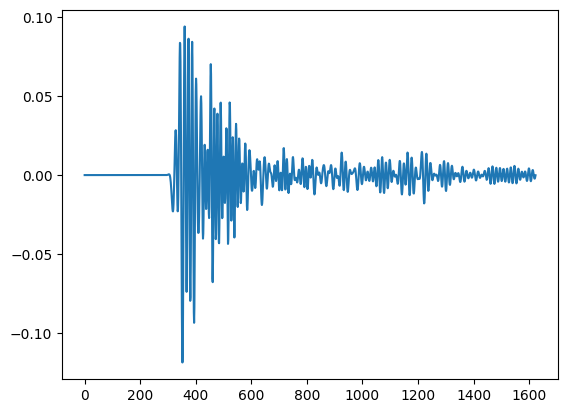

In [7]:
plt.plot(traza)

In [8]:
traza_decon= wiener_deconvolution_sismic(traza, h, noise_var)

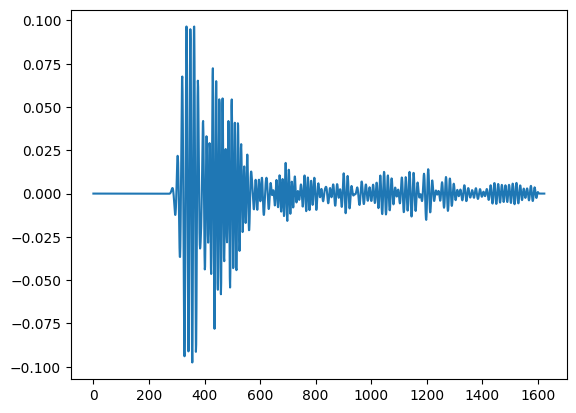

In [9]:
plt.plot(traza_decon)

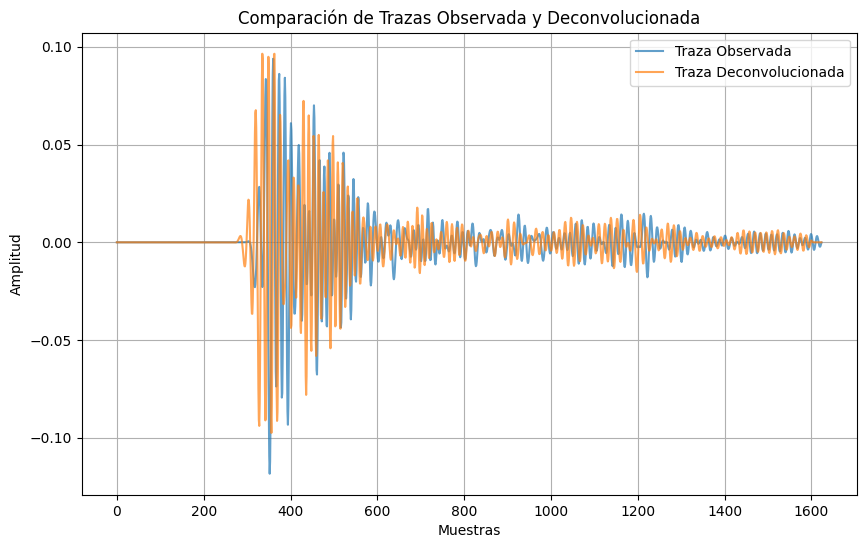

In [10]:
# Graficar las trazas
plt.figure(figsize=(10, 6))
plt.plot(traza, label='Traza Observada', alpha=0.7)
plt.plot(traza_decon, label='Traza Deconvolucionada', alpha=0.7)
plt.xlabel('Muestras')
plt.ylabel('Amplitud')
plt.title('Comparación de Trazas Observada y Deconvolucionada')
plt.legend()
plt.grid()
plt.show()

In [12]:
data.shape

(330, 1624)

In [18]:
data_decon=data*0
for i in range(data.shape[0]):
    data_decon[i]= wiener_deconvolution_sismic(data[i], h, noise_var)
    
    


In [19]:
data_decon.shape

(330, 1624)

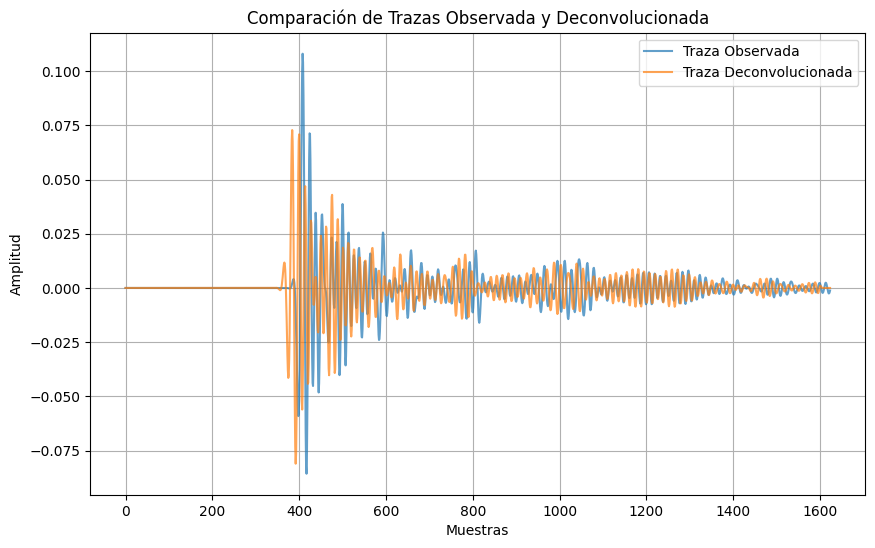

In [24]:
# Graficar las trazas
plt.figure(figsize=(10, 6))
plt.plot(data[100], label='Traza Observada', alpha=0.7)
plt.plot(data_decon[100], label='Traza Deconvolucionada', alpha=0.7)
plt.xlabel('Muestras')
plt.ylabel('Amplitud')
plt.title('Comparación de Trazas Observada y Deconvolucionada')
plt.legend()
plt.grid()
plt.show()

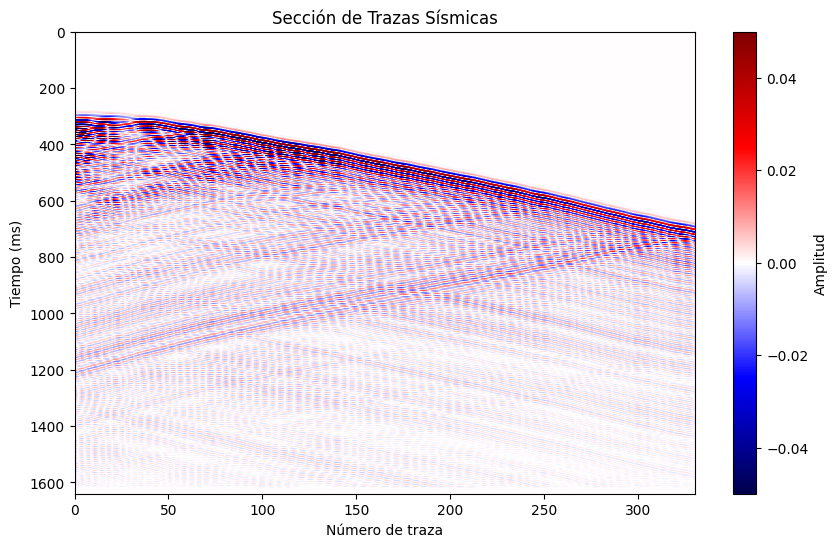

In [22]:
# Configuración para graficar las trazas sísmicas
clip = 5e-2
vmin, vmax = -clip, clip
plt.figure(figsize=(10, 6))
plt.imshow(data_decon.T, aspect='auto', cmap='seismic', extent=[0, 330, 1640, 0], vmin=vmin, vmax=vmax)
plt.colorbar(label="Amplitud")
plt.xlabel("Número de traza")
plt.ylabel("Tiempo (ms)")
plt.title("Sección de Trazas Sísmicas")
plt.show()